In [3]:
"""
╔══════════════════════════════════════════════════════════════════╗
║         PORTFOLIO RISK ANALYSIS FRAMEWORK — ADVANCED             ║
║                                                                  ║
║  ENTRY POINT:                                                    ║
║    result = analyze_portfolio(portfolio, horizon_years=20)       ║
║                                                                  ║
║  INPUTS:                                                         ║
║    portfolio      : list[dict]  {"ticker", "allocation"}         ║
║    horizon_years  : int         investment horizon in years      ║
║    lookback_years : int         historical window (default 5)    ║
║    save_dashboard : bool        save PNG (default True)          ║
║                                                                  ║
║  OUTPUTS:                                                        ║
║    dict: metrics, stress, var_mc, garch, prices, macro           ║
║                                                                  ║
║  REQUIREMENTS:                                                   ║
║    pip install yfinance pandas numpy scipy arch tabulate         ║
║                matplotlib seaborn pandas-datareader              ║
╚══════════════════════════════════════════════════════════════════╝
"""

# ──────────────────────────────────────────────────────────────────
# BLOCK 0 — IMPORTS AND GLOBAL CONFIGURATION
#
# WHAT IT DOES: imports all required libraries and defines global
# constants used throughout the framework (risk-free rate, trading
# days, VaR confidence level, MC simulations, and stress scenarios).
# Centralizing them here allows easy recalibration without touching
# internal logic.
#
# DEPENDENCIES: none (starting point)
# USED IN: all subsequent blocks
# ──────────────────────────────────────────────────────────────────

import warnings; warnings.filterwarnings("ignore")
import yfinance as yf
import pandas as pd
import numpy as np
from scipy import stats
from arch import arch_model
from tabulate import tabulate
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta

try:
    import pandas_datareader.data as web
    FRED_AVAILABLE = True
except ImportError:
    FRED_AVAILABLE = False

# Global parameters — adjust here to recalibrate the framework
RISK_FREE_RATE  = 0.05      # Annualized risk-free rate (T-bill reference)
TRADING_DAYS    = 252       # Trading days per year
CONFIDENCE_VAR  = 0.95      # Confidence level for VaR/CVaR
MC_SIMULATIONS  = 10_000    # Monte Carlo simulations

# Stress scenarios: historical periods and real factor shocks
# (SPY, TLT, GLD) during each crisis — used in BLOCK 6
STRESS_PERIODS = {
    "2008 Crisis": ("2008-09-01", "2009-03-31"),
    "COVID-19":    ("2020-02-19", "2020-03-23"),
}
STRESS_FACTOR_RETURNS = {
    "2008 Crisis": {"SPY": -0.465, "TLT":  0.258, "GLD":  0.192},
    "COVID-19":    {"SPY": -0.340, "TLT":  0.198, "GLD": -0.012},
}

# ──────────────────────────────────────────────────────────────────
# BLOCK 1 — PORTFOLIO PREPARATION
#
# WHAT IT DOES: validates and normalizes allocations, injects the
# investment horizon into each asset, and separates CASH from
# tradeable assets. CASH has zero return and zero volatility by
# definition and cannot be downloaded via yfinance — it is treated
# as a portfolio weight only.
#
# WHY THIS WAY: normalization handles inputs that don't sum exactly
# to 1.0 (rounding errors or user convenience). Copying the dict
# prevents accidental mutation of the original input.
#
# DEPENDENCIES: none
# USED IN: all calculation blocks (active_port, cash_alloc)
# ──────────────────────────────────────────────────────────────────

def _prepare_portfolio(portfolio, horizon_years):
    portfolio = [dict(a) for a in portfolio]        # defensive copy
    for a in portfolio:
        a["horizon_years"] = horizon_years

    total = sum(a["allocation"] for a in portfolio)
    if abs(total - 1.0) > 0.01:
        print(f"⚠️  Allocations sum to {total:.4f} — normalizing automatically.")
        for a in portfolio:
            a["allocation"] /= total

    cash_alloc  = next((a["allocation"] for a in portfolio if a["ticker"] == "CASH"), 0.0)
    active_port = [a for a in portfolio if a["ticker"] != "CASH"]
    return active_port, cash_alloc

# ──────────────────────────────────────────────────────────────────
# BLOCK 2 — HISTORICAL PRICE FETCH
#
# WHAT IT DOES: downloads adjusted closing prices for all assets
# via yfinance and applies a gap-filling strategy that preserves
# the integrity of the historical analysis:
#
#   1. ffill (forward fill): propagates the last valid price to
#      days with no quote (local holidays, temporary halts).
#      Correct because the asset price didn't change — the market
#      was simply closed.
#
#   2. Assets with a shorter history than the lookback window
#      (e.g. ETFs listed after the start of the window) are NOT
#      back-filled or interpolated retroactively — that would
#      introduce fictitious zero returns at the start of the series,
#      distorting vol, Sharpe, and correlations. Instead, the asset
#      is included only from its first available date and excluded
#      from return calculations on prior days (handled in BLOCK 3
#      via dynamic weight reallocation).
#
#   3. dropna(how="all") removes only dates where NO asset has
#      data (weekends, non-trading days), preserving dates where
#      only some assets have gaps.
#
# DEPENDENCIES: BLOCK 1 (active_port)
# USED IN: BLOCK 3 (compute_metrics), BLOCK 11 (dashboard)
# ──────────────────────────────────────────────────────────────────

def _fetch_data(active_port, lookback_years=5):
    tickers = [a["ticker"] for a in active_port]
    start   = (datetime.today() - timedelta(days=lookback_years * 365)).strftime("%Y-%m-%d")
    raw     = yf.download(tickers, start=start, auto_adjust=True, progress=False)["Close"]
    if isinstance(raw, pd.Series):
        raw = raw.to_frame(tickers[0])

    # Step 1: forward fill — fills holidays and temporary halts
    # without fabricating retroactive data
    raw.ffill(inplace=True)

    # Step 2: remove only rows where absolutely no asset has data
    raw.dropna(how="all", inplace=True)

    # Step 3: report assets with incomplete history for transparency
    n_total = len(raw)
    for t in tickers:
        n_valid = raw[t].notna().sum()
        if n_valid < n_total:
            first = raw[t].first_valid_index()
            print(f"   ⚠️  {t}: history starts {first.date()} "
                  f"({n_valid}/{n_total} days — excluded from calculations before listing)")
    return raw

# ──────────────────────────────────────────────────────────────────
# BLOCK 3 — PORTFOLIO METRICS
#
# WHAT IT DOES: computes all quantitative return and risk metrics
# for individual assets and the aggregated portfolio:
#   • Annualized return and volatility per asset
#   • Sharpe and Sortino per asset and portfolio
#   • Beta of each asset vs SPY (via simple OLS)
#   • Historical VaR and CVaR of the portfolio
#   • Max Drawdown (largest peak-to-trough decline)
#   • Horizon return projection (expected and 95% downside)
#   • Correlation matrix
#
# WHY THIS WAY: allocations are normalized including CASH (which
# contributes 0 return) so weights reflect the real portfolio. Beta
# is computed via OLS rather than simple correlation for better
# stability with series of different lengths. Sortino uses only
# returns < 0 in the denominator — more realistic than Sharpe for
# loss-averse investors. For days where an asset has no data yet
# (before its listing), its weight is dynamically reallocated
# among available assets to avoid fictitious zero returns.
#
# DEPENDENCIES: BLOCK 2 (prices), BLOCK 1 (active_port, cash_alloc)
# USED IN: BLOCKS 4, 5, 6, 7, 8, 8b, 11 (full dashboard)
# ──────────────────────────────────────────────────────────────────

def _compute_metrics(prices, active_port, cash_alloc):
    returns    = prices.pct_change().dropna(how="all")
    tickers    = [a["ticker"] for a in active_port]
    raw_allocs = np.array([a["allocation"] for a in active_port])

    # Real weight of each asset in the total portfolio (including CASH)
    allocs = raw_allocs / (raw_allocs.sum() + cash_alloc)

    # ── Individual annualized statistics
    # Each asset uses only its own valid trading days
    ann_ret = returns.mean() * TRADING_DAYS
    ann_vol = returns.std()  * np.sqrt(TRADING_DAYS)
    sharpe  = (ann_ret - RISK_FREE_RATE) / ann_vol

    # Sortino: denominator uses only negative returns (downside deviation)
    downside_dev = returns.apply(lambda c: c[c < 0].std() * np.sqrt(TRADING_DAYS))
    sortino = (ann_ret - RISK_FREE_RATE) / downside_dev

    # ── Beta vs SPY (OLS: r_asset ~ r_SPY)
    spy_ret  = yf.download("SPY", start=prices.index[0].strftime("%Y-%m-%d"),
                           auto_adjust=True, progress=False)["Close"].pct_change().dropna()
    beta_mkt = {}
    for t in tickers:
        s  = returns[t].dropna()        # only valid days for this asset
        mv = spy_ret.reindex(s.index).dropna()
        s  = s.reindex(mv.index)
        slope, *_ = stats.linregress(mv.values.flatten(), s.values.flatten())
        beta_mkt[t] = round(float(slope), 3)

    # ── Daily portfolio return
    # On days where an asset has no data yet (NaN), its weight is
    # redistributed proportionally among available assets — avoids
    # the portfolio appearing to have lower returns due to a "zero position"
    alloc_series = pd.Series(allocs, index=tickers)
    port_ret = returns.apply(
        lambda row: (
            row.dropna() * alloc_series[row.dropna().index] /
            alloc_series[row.dropna().index].sum()
        ).sum() if row.notna().any() else np.nan,
        axis=1
    ).dropna()

    port_ann_ret  = port_ret.mean() * TRADING_DAYS
    port_ann_vol  = port_ret.std()  * np.sqrt(TRADING_DAYS)
    port_sharpe   = (port_ann_ret - RISK_FREE_RATE) / port_ann_vol
    port_downside = port_ret[port_ret < 0].std() * np.sqrt(TRADING_DAYS)
    port_sortino  = (port_ann_ret - RISK_FREE_RATE) / port_downside

    # ── Historical VaR and CVaR (non-parametric)
    var_hist  = np.percentile(port_ret, (1 - CONFIDENCE_VAR) * 100)
    cvar_hist = port_ret[port_ret <= var_hist].mean()

    # ── Max Drawdown
    cum    = (1 + port_ret).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()

    # ── Horizon projection (simple compounding + 95% downside)
    horizon_proj = {
        a["ticker"]: {
            "expected":    (1 + float(ann_ret[a["ticker"]])) ** a["horizon_years"] - 1,
            "downside_95": (1 + float(ann_ret[a["ticker"]]) - 1.65 *
                           float(ann_vol[a["ticker"]]) / np.sqrt(a["horizon_years"])) ** a["horizon_years"] - 1,
            "horizon": a["horizon_years"],
        }
        for a in active_port
    }

    return {
        "returns": returns, "ann_ret": ann_ret, "ann_vol": ann_vol,
        "sharpe": sharpe, "sortino": sortino, "beta": beta_mkt,
        "port_ann_ret": port_ann_ret, "port_ann_vol": port_ann_vol,
        "port_sharpe": port_sharpe, "port_sortino": port_sortino,
        "var_hist": var_hist, "cvar_hist": cvar_hist,
        "max_dd": max_dd, "corr": returns.corr(),
        "horizon_proj": horizon_proj, "port_series": port_ret,
        "allocs": allocs, "tickers": tickers,
    }

# ──────────────────────────────────────────────────────────────────
# BLOCK 4 — MONTE CARLO VaR
#
# WHAT IT DOES: simulates MC_SIMULATIONS daily portfolio returns
# assuming a normal distribution with historical μ and σ, and
# extracts the parametric VaR and CVaR from the simulated distribution.
#
# WHY THIS WAY: complements the historical VaR (BLOCK 3) with a
# parametric estimate — useful when the historical window is short
# or when exploring scenarios beyond observed history. The comparison
# between historical and MC VaR reveals whether real return
# distribution has heavier tails than normal.
#
# DEPENDENCIES: BLOCK 3 (port_ann_ret, port_ann_vol)
# USED IN: BLOCK 8 (report), BLOCK 11 (dashboard — histogram)
# ──────────────────────────────────────────────────────────────────

def _monte_carlo_var(m):
    mu  = m["port_ann_ret"] / TRADING_DAYS
    sig = m["port_ann_vol"] / np.sqrt(TRADING_DAYS)
    sim = np.random.normal(mu, sig, MC_SIMULATIONS)
    var_mc  = np.percentile(sim, (1 - CONFIDENCE_VAR) * 100)
    cvar_mc = sim[sim <= var_mc].mean()
    return var_mc, cvar_mc, sim

# ──────────────────────────────────────────────────────────────────
# BLOCK 5 — GARCH(1,1) — CONDITIONAL VOLATILITY
#
# WHAT IT DOES: fits a GARCH(1,1) model to the portfolio's historical
# returns and forecasts conditional volatility for the next 21 trading
# days (~1 month).
#
# WHY THIS WAY: simple historical volatility assumes constant variance
# — it ignores "volatility clustering" (high-vol periods tend to
# persist). GARCH captures this dynamic. Returns are scaled ×100 for
# numerical stability of the MLE optimizer, then unscaled before
# returning.
#
# DEPENDENCIES: BLOCK 3 (port_series)
# USED IN: BLOCK 8 (report), BLOCK 11 (dashboard — GARCH chart)
# ──────────────────────────────────────────────────────────────────

def _fit_garch(port_ret_series, horizon_days=21):
    r_scaled  = port_ret_series * 100
    res       = arch_model(r_scaled, vol="Garch", p=1, q=1,
                           dist="normal", rescale=False).fit(disp="off")
    forecast  = res.forecast(horizon=horizon_days)
    daily_vol = np.sqrt(forecast.variance.values[-1]) / 100
    return daily_vol, daily_vol[-1] * np.sqrt(TRADING_DAYS)

# ──────────────────────────────────────────────────────────────────
# BLOCK 6 — STRESS TESTING (macro factor model)
#
# WHAT IT DOES: estimates how the portfolio would have behaved during
# the 2008 crisis and COVID-19, using a multifactor model (SPY, TLT,
# GLD). For each asset, betas are estimated via OLS and real factor
# shocks are applied to estimate returns under each crisis scenario.
#
# WHY THIS WAY: most ETFs didn't exist in 2008, making direct
# historical stress testing impossible. The factor model solves this:
# it uses betas estimated from available history to extrapolate
# behavior in historical scenarios not covered by the data. The
# daily trajectory is simulated with noise proportional to historical
# vol to generate a realistic curve for the dashboard.
#
# DEPENDENCIES: BLOCK 3 (returns, allocs, tickers, port_ann_vol)
# USED IN: BLOCK 8 (report), BLOCK 11 (dashboard — stress panel)
# ──────────────────────────────────────────────────────────────────

def _stress_test(m):
    tickers = m["tickers"]; allocs = m["allocs"]; returns = m["returns"]

    # Download the 3 reference factors for the same historical period
    factor_raw  = yf.download(["SPY", "TLT", "GLD"],
                              start=returns.index[0].strftime("%Y-%m-%d"),
                              auto_adjust=True, progress=False)["Close"]
    factor_rets = factor_raw.pct_change().dropna()

    # Multifactor OLS per asset: r = α + β_SPY·r_SPY + β_TLT·r_TLT + β_GLD·r_GLD
    factor_betas = {}
    for t in tickers:
        if t not in returns.columns:
            factor_betas[t] = {"SPY": 1.0, "TLT": 0.0, "GLD": 0.0}
            continue
        y     = returns[t].dropna()
        X     = factor_rets.reindex(y.index).dropna()
        y     = y.reindex(X.index)
        X_mat = np.column_stack([np.ones(len(X)), X["SPY"].values,
                                 X["TLT"].values, X["GLD"].values])
        try:
            coefs, *_ = np.linalg.lstsq(X_mat, y.values, rcond=None)
            factor_betas[t] = {"SPY": coefs[1], "TLT": coefs[2], "GLD": coefs[3]}
        except Exception:
            factor_betas[t] = {"SPY": 1.0, "TLT": 0.0, "GLD": 0.0}

    results = {}
    for name, shocks in STRESS_FACTOR_RETURNS.items():
        start, end = STRESS_PERIODS[name]

        # Estimated return of each asset under macro shock
        asset_ret  = {t: sum(factor_betas[t][f] * shocks[f] for f in shocks) for t in tickers}
        port_total = sum(asset_ret[t] * allocs[i] for i, t in enumerate(tickers))

        # Simulated daily path (mean return + noise at 30% of historical vol)
        n_days  = len(pd.bdate_range(start, end))
        daily_r = (1 + port_total) ** (1 / n_days) - 1
        np.random.seed(42)
        noise   = np.random.normal(0, m["port_ann_vol"] / np.sqrt(TRADING_DAYS) * 0.3, n_days)
        cum     = pd.Series((1 + daily_r + noise).cumprod(),
                            index=pd.bdate_range(start, periods=n_days))

        results[name] = {
            "total_ret": port_total,
            "max_dd":    ((cum - cum.cummax()) / cum.cummax()).min(),
            "series":    cum,
            "asset_ret": asset_ret,
            "contrib":   {t: asset_ret[t] * allocs[i] for i, t in enumerate(tickers)},
        }
    return results

# ──────────────────────────────────────────────────────────────────
# BLOCK 7 — COMPOSITE RISK SCORE (1–10)
#
# WHAT IT DOES: synthesizes volatility, drawdown, and VaR into a
# single 1–10 score for intuitive risk communication.
#
# WHY THIS WAY: each component is normalized by a reference
# threshold (vol 30%, DD 50%, VaR 10%) and combined with weights
# reflecting relative importance: vol 40%, DD 40%, VaR 20%.
# The result is capped at 10 to avoid aberrant scores for
# extremely volatile portfolios (e.g. pure crypto).
#
# DEPENDENCIES: BLOCK 3 (port_ann_vol, max_dd, var_hist)
# USED IN: BLOCK 8b (narrative), BLOCK 11 (metric cards)
# ──────────────────────────────────────────────────────────────────

def _risk_score(m):
    composite = (min(10, m["port_ann_vol"] / 0.03) * 0.4 +
                 min(10, abs(m["max_dd"])   / 0.05) * 0.4 +
                 min(10, abs(m["var_hist"]) / 0.01) * 0.2)
    label = ("🟢 Conservative" if composite < 3 else
             "🟡 Moderate"    if composite < 5 else
             "🟠 Aggressive"  if composite < 7 else
             "🔴 Very High Risk")
    return round(composite, 2), label

# ──────────────────────────────────────────────────────────────────
# BLOCK 8 — QUANTITATIVE REPORT (terminal)
#
# WHAT IT DOES: prints formatted tables with all metrics computed
# in previous blocks. Organized into 4 sections:
#   1. Asset Breakdown — individual metrics per asset
#   2. Portfolio Summary — aggregated metrics + GARCH + VaR
#   3. Rankings — top/bottom assets across each dimension
#   4. Stress Test — estimated crisis scenario results
#
# WHY THIS WAY: the report is separated from the visual dashboard
# so it can be used in display-less environments (servers, CI/CD).
# Tables use tabulate with rounded_outline for clean terminal output.
#
# DEPENDENCIES: BLOCKS 3, 4, 5, 6, 7
# USED IN: terminal output (returns nothing)
# ──────────────────────────────────────────────────────────────────

def _print_report(m, stress, var_mc, cvar_mc, ann_vol_garch, cash_alloc, horizon):
    tickers = m["tickers"]; allocs = m["allocs"]
    score, label = _risk_score(m)

    print("\n" + "═"*68)
    print("   PORTFOLIO RISK ANALYSIS REPORT — ADVANCED")
    print(f"   Generated: {datetime.today().strftime('%Y-%m-%d %H:%M')}   "
          f"| Horizon: {horizon}y | Lookback: 5y")
    print("═"*68)

    # ── Section 1: Asset Breakdown
    ret_total = {}
    rows = []
    for i, t in enumerate(tickers):
        r = float(m["ann_ret"][t]); v = float(m["ann_vol"][t])
        tot = (1 + r) ** horizon - 1
        ret_total[t] = tot
        rows.append([t, f"{allocs[i]*100:.1f}%", f"{r*100:.1f}%", f"{v*100:.1f}%",
                     f"{float(m['sharpe'][t]):.2f}", f"{float(m['sortino'][t]):.2f}",
                     f"{m['beta'][t]:.2f}", f"{tot*100:.1f}%"])
    if cash_alloc > 0:
        rows.append(["CASH", f"{cash_alloc*100:.1f}%", "0.0%", "0.0%",
                     "—", "—", "—", "0.0%"])
    print("\n📊 ASSET BREAKDOWN")
    print(tabulate(rows,
                   headers=["Ticker", "Alloc", "Ann.Ret", "Ann.Vol",
                             "Sharpe", "Sortino", "Beta", f"Total({horizon}y)"],
                   tablefmt="rounded_outline"))

    # ── Section 2: Portfolio Summary
    port_total_h = (1 + m["port_ann_ret"]) ** horizon - 1
    print(f"\n📈 PORTFOLIO SUMMARY — {horizon}-year horizon")
    print(tabulate([
        ["Expected Annual Return",              f"{m['port_ann_ret']*100:.2f}%"],
        [f"Compounded Total Return ({horizon}y)", f"{port_total_h*100:.1f}%"],
        ["Annual Volatility (historical)",      f"{m['port_ann_vol']*100:.2f}%"],
        ["GARCH Vol Forecast (21d)",            f"{ann_vol_garch*100:.2f}%"],
        ["Sharpe Ratio",                        f"{m['port_sharpe']:.2f}"],
        ["Sortino Ratio",                       f"{m['port_sortino']:.2f}"],
        ["Max Drawdown",                        f"{m['max_dd']*100:.2f}%"],
        ["VaR Historical 1d (95%)",             f"{m['var_hist']*100:.2f}%"],
        ["VaR Monte Carlo 1d (95%)",            f"{var_mc*100:.2f}%"],
        ["CVaR Historical 1d (95%)",            f"{m['cvar_hist']*100:.2f}%"],
        ["CVaR Monte Carlo 1d (95%)",           f"{cvar_mc*100:.2f}%"],
        ["Risk Score (1–10)",                   f"{score}  {label}"],
    ], tablefmt="rounded_outline"))

    # ── Section 3: Rankings
    def _top3(d, rev=True): return sorted(d.items(), key=lambda x: x[1], reverse=rev)[:3]
    def _fmt(p): return "  ".join(f"{t} ({v*100:.1f}%)" for t, v in p)
    alloc_d = {t: allocs[i] for i, t in enumerate(tickers)}
    ann_r_d = {t: float(m["ann_ret"][t]) for t in tickers}
    ann_v_d = {t: float(m["ann_vol"][t]) for t in tickers}
    print(f"\n📌 RANKINGS — {horizon}-year horizon")
    print(tabulate([
        ["Top 3 Allocation",                         _fmt(_top3(alloc_d))],
        ["Top 3 Highest Volatility",                 _fmt(_top3(ann_v_d))],
        ["Top 3 Lowest Volatility",                  _fmt(_top3(ann_v_d, rev=False))],
        ["Top 3 Highest Annual Return",              _fmt(_top3(ann_r_d))],
        ["Top 3 Lowest Annual Return",               _fmt(_top3(ann_r_d, rev=False))],
        [f"Top 3 Highest Total Return ({horizon}y)", _fmt(_top3(ret_total))],
        [f"Top 3 Lowest Total Return ({horizon}y)",  _fmt(_top3(ret_total, rev=False))],
    ], headers=["Category", "Assets"], tablefmt="rounded_outline"))

    # ── Section 4: Stress Test
    print("\n🔥 STRESS TEST (macro factor simulation — SPY, TLT, GLD)")
    for name, res in stress.items():
        if not res.get("total_ret"): continue
        print(f"\n  {name}  →  Return: {res['total_ret']*100:.1f}%  "
              f"|  Max DD: {res['max_dd']*100:.1f}%")
        print(tabulate(
            [[t, f"{res['asset_ret'][t]*100:.1f}%", f"{c*100:.2f}%"]
             for t, c in sorted(res["contrib"].items(), key=lambda x: x[1])],
            headers=["Asset", "Est. Return", "Contribution"],
            tablefmt="simple"))
    print("\n" + "═"*68)

# ──────────────────────────────────────────────────────────────────
# BLOCK 8b — ANALYTICAL NARRATIVE (terminal)
#
# WHAT IT DOES: generates a detailed analytical report explaining
# each risk metric in the framework — what it is, how it measures,
# the result for this specific portfolio, why the metric matters,
# and its limitations. Also includes a portfolio overview with
# return highlights and diversification assessment.
#
# WHY THIS WAY: the quantitative report (BLOCK 8) presents numbers
# — this block contextualizes them. The goal is for an investor
# without technical training to understand what each number means
# and what decisions it informs.
#
# DEPENDENCIES: BLOCKS 3, 5, 6, 7
# USED IN: terminal output (returns nothing)
# ──────────────────────────────────────────────────────────────────

def _portfolio_narrative(m, stress, var_mc, ann_vol_garch, cash_alloc, horizon):
    tickers = m["tickers"]; allocs = m["allocs"]
    score, label = _risk_score(m)

    # Pre-computations used throughout the narrative
    alloc_dict   = {t: allocs[i] for i, t in enumerate(tickers)}
    top3_alloc   = sorted(alloc_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    top3_ret     = sorted({t: float(m["ann_ret"][t]) for t in tickers}.items(), key=lambda x: x[1], reverse=True)[:3]
    bot3_ret     = sorted({t: float(m["ann_ret"][t]) for t in tickers}.items(), key=lambda x: x[1])[:3]
    top3_vol     = sorted({t: float(m["ann_vol"][t]) for t in tickers}.items(), key=lambda x: x[1], reverse=True)[:3]
    bot3_vol     = sorted({t: float(m["ann_vol"][t]) for t in tickers}.items(), key=lambda x: x[1])[:3]
    port_total_h = (1 + m["port_ann_ret"]) ** horizon - 1
    corr_vals    = m["corr"].values
    avg_corr     = float(np.nanmean(corr_vals[np.triu_indices_from(corr_vals, k=1)]))
    corr_desc    = "low" if avg_corr < 0.3 else "moderate" if avg_corr < 0.6 else "high"
    sharpe_desc  = "weak" if m["port_sharpe"] < 0.5 else "reasonable" if m["port_sharpe"] < 1.0 else "strong"
    sortino_desc = "weak" if m["port_sortino"] < 0.5 else "reasonable" if m["port_sortino"] < 1.0 else "strong"
    garch_ann    = ann_vol_garch * 100
    garch_dir    = "above" if garch_ann > m["port_ann_vol"]*100 else "below"
    stress_lines = [f"{n}: return {r['total_ret']*100:.1f}%, DD {r['max_dd']*100:.1f}%"
                    for n, r in stress.items() if r.get("total_ret") is not None]
    stress_vuln  = any(r.get("total_ret", 0) < -0.15
                       for r in stress.values() if r.get("total_ret") is not None)
    W = 68

    def _sec(n, title):
        print(f"\n{'─'*W}")
        print(f"  {n}. {title.upper()}")
        print(f"{'─'*W}")

    print("\n" + "═"*W)
    print("   PORTFOLIO NARRATIVE — FULL ANALYTICAL REPORT")
    print(f"   {datetime.today().strftime('%Y-%m-%d %H:%M')}   "
          f"|  {len(tickers)} assets  |  {horizon}-year horizon")
    print("═"*W)

    # ── 1. Portfolio Overview
    _sec(1, "Portfolio Overview")
    print(f"""
Composition: {len(tickers)} tradeable assets + {cash_alloc*100:.1f}% cash position.
Investment horizon: {horizon} years.

Historical annualized return (5y):     {m['port_ann_ret']*100:.1f}%
Expected compounded total return ({horizon}y): {port_total_h*100:.0f}%
Annualized volatility:                 {m['port_ann_vol']*100:.1f}%
Risk Score:                            {score}/10 — {label}

Top 3 positions: {', '.join(f"{t} ({v*100:.1f}%)" for t,v in top3_alloc)}
→ Concentration in top 3: {sum(v for _,v in top3_alloc)*100:.1f}% of total portfolio.

Highest returns: {', '.join(f"{t} ({v*100:.1f}%/y)" for t,v in top3_ret)}
Lowest returns:  {', '.join(f"{t} ({v*100:.1f}%/y)" for t,v in bot3_ret)}
Most volatile:   {', '.join(f"{t} ({v*100:.1f}%)" for t,v in top3_vol)}
Least volatile:  {', '.join(f"{t} ({v*100:.1f}%)" for t,v in bot3_vol)}
""")

    # ── 2. Sharpe Ratio
    _sec(2, "Sharpe Ratio — Risk-Adjusted Return (Total Risk)")
    print(f"""
WHAT IT IS:
  Measures excess return per unit of total risk (volatility).
  Developed by William Sharpe (1966), it is the most widely used
  portfolio efficiency metric globally.

HOW IT MEASURES:
  Sharpe = (Portfolio Return − Risk-Free Rate) / Annual Volatility
  Risk-free rate used: {RISK_FREE_RATE*100:.1f}% p.a.

RESULT:
  Sharpe for this portfolio: {m['port_sharpe']:.2f} → {sharpe_desc.upper()}
  Reference: < 0.5 weak | 0.5–1.0 reasonable | > 1.0 strong

IMPORTANCE:
  Allows comparing portfolios with different risk profiles on equal
  footing. A high Sharpe indicates that returns adequately compensate
  for total risk taken.

LIMITATIONS:
  • Assumes normally distributed returns — ignores fat tails.
  • Penalizes upside and downside volatility equally.
  • Sensitive to the analysis period and risk-free rate choice.
""")

    # ── 3. Sortino Ratio
    _sec(3, "Sortino Ratio — Risk-Adjusted Return (Downside Risk Only)")
    print(f"""
WHAT IT IS:
  Sharpe variant that penalizes only downside volatility (negative
  returns). Developed by Frank Sortino (1980s).

HOW IT MEASURES:
  Sortino = (Return − Risk-Free Rate) / Std Dev of negative returns only
  Only days with return < 0 enter the denominator.

RESULT:
  Sortino for this portfolio: {m['port_sortino']:.2f} → {sortino_desc.upper()}
  {"Sortino > Sharpe: volatility is predominantly from upside moves — a positive sign." if m['port_sortino'] > m['port_sharpe'] else "Sharpe ≈ Sortino: relatively symmetric return distribution."}

IMPORTANCE:
  Better aligned with real investor risk perception — investors worry
  about losses, not unexpected gains. Preferred for strategies with
  asymmetric return profiles.

LIMITATIONS:
  • Requires sufficient history of negative returns for a stable estimate.
  • May overstate quality of portfolios during extended bull markets
    with few negative days.
""")

    # ── 4. Historical VaR and CVaR
    _sec(4, "Historical VaR and CVaR — Tail Risk (Non-Parametric)")
    print(f"""
WHAT IT IS:
  VaR (Value at Risk): maximum expected 1-day loss at a given confidence
  level, computed directly from the empirical return distribution.
  CVaR (Expected Shortfall): average loss in scenarios worse than VaR.

HOW IT MEASURES:
  VaR: (1 − confidence) percentile of the historical daily return series.
  CVaR: mean of returns below VaR.
  Confidence level used: {int(CONFIDENCE_VAR*100)}%

RESULT:
  Historical VaR 1d (95%):  {m['var_hist']*100:.2f}% → in 95% of days, the loss
                             will not exceed this value.
  Historical CVaR 1d (95%): {m['cvar_hist']*100:.2f}% → when VaR is breached, this
                             is the expected average loss.

IMPORTANCE:
  CVaR is the tail risk metric recommended by Basel III. It captures
  what happens beyond VaR — exactly what matters in a crisis.

LIMITATIONS:
  • Assumes the future will behave like the historical past.
  • Does not capture events without historical precedent (black swans).
  • Underestimates risk during low-volatility pre-crisis periods.
""")

    # ── 5. Monte Carlo VaR
    _sec(5, "Monte Carlo VaR — Tail Risk (Parametric)")
    print(f"""
WHAT IT IS:
  Simulates {MC_SIMULATIONS:,} daily return scenarios from a parametric model
  (normal distribution) and extracts the loss percentile.

HOW IT MEASURES:
  Daily μ = {m['port_ann_ret']/TRADING_DAYS*100:.4f}%  (historical mean daily return)
  Daily σ = {m['port_ann_vol']/np.sqrt(TRADING_DAYS)*100:.4f}%  (historical daily volatility)
  MC VaR = {int((1-CONFIDENCE_VAR)*100)}th percentile of the simulated distribution.

RESULT:
  Monte Carlo VaR 1d (95%): {var_mc*100:.2f}%
  {"→ Convergence with historical VaR — parametric model is consistent." if abs(var_mc - m['var_hist']) < 0.002 else f"→ Divergence of {abs(var_mc - m['var_hist'])*100:.2f}pp vs historical VaR — real distribution may have fatter tails than normal."}

IMPORTANCE:
  Enables scenario simulation beyond observed history. Useful when
  the historical window is short. The comparison with historical VaR
  reveals whether the real distribution has fat tails.

LIMITATIONS:
  • Assumes normality — underestimates extreme events.
  • Sensitive to μ and σ estimates, which change over time.
  • Does not capture dynamic inter-asset correlations during crises.
""")

    # ── 6. GARCH(1,1)
    _sec(6, "GARCH(1,1) — Conditional Future Volatility")
    print(f"""
WHAT IT IS:
  Time series model that captures "volatility clustering": high-vol
  periods tend to persist. Introduced by Bollerslev (1986), it is
  the industry standard for volatility modeling.

HOW IT MEASURES:
  σ²_t = ω + α·ε²_(t-1) + β·σ²_(t-1)
  Estimated by maximum likelihood. Projects volatility for the next
  21 trading days (~1 month).

RESULT:
  Historical annualized volatility:  {m['port_ann_vol']*100:.1f}%
  GARCH projected volatility (21d):  {garch_ann:.1f}%
  → Projection is {garch_dir} historical average.
  → {"Increasing uncertainty in the near term — heightened risk vigilance advised." if garch_dir == "above" else "Relatively stable environment ahead — volatility expected to revert to mean."}

IMPORTANCE:
  While historical vol is static, GARCH is dynamic: it updates the
  risk estimate with each new return, reflecting the current market
  environment. Essential for derivatives pricing and dynamic VaR.

LIMITATIONS:
  • Simple GARCH(1,1) doesn't capture asymmetry (losses increase vol
    more than gains) — for that: EGARCH or GJR-GARCH.
  • Forecasts converge to unconditional vol beyond ~30 days.
  • Sensitive to extreme outliers at the start of the series.
""")

    # ── 7. Max Drawdown
    _sec(7, "Max Drawdown — Path Risk")
    print(f"""
WHAT IT IS:
  The largest cumulative decline of the portfolio from a historical
  peak to the subsequent trough before a new recovery. Captures the
  "worst case scenario" an investor would have experienced in the period.

HOW IT MEASURES:
  MDD = min[(Value_t − Peak_t) / Peak_t]  for all t in the period.

RESULT:
  Historical Max Drawdown: {m['max_dd']*100:.1f}%
  {"→ Contained decline — portfolio demonstrated good resilience over the past 5 years." if abs(m['max_dd']) < 0.20 else "→ Significant decline — investor needed considerable psychological and financial tolerance to hold through the drawdown."}

IMPORTANCE:
  The most intuitive risk metric for long-term investors. Complements
  VaR by capturing path risk — not just the worst day, but the worst
  cumulative sequence of days.

LIMITATIONS:
  • Backward-looking only — does not constrain the next drawdown.
  • Does not capture speed or duration of the decline.
  • Dependent on the chosen analysis period.
""")

    # ── 8. Stress Testing
    _sec(8, "Stress Testing — Macro Factor Simulation")
    print(f"""
WHAT IT IS:
  Estimates how the portfolio would have behaved during the 2008 crisis
  and COVID-19, using a multifactor model (SPY, TLT, GLD) instead of
  direct historical ETF data (most didn't exist in 2008).

HOW IT MEASURES:
  1. OLS: r_asset = α + β_SPY·r_SPY + β_TLT·r_TLT + β_GLD·r_GLD
  2. Applied shocks (real factor returns during each crisis):
     2008 Crisis → SPY −46.5%, TLT +25.8%, GLD +19.2%
     COVID-19    → SPY −34.0%, TLT +19.8%, GLD −1.2%
  3. Est. portfolio return = Σ(β_factor × shock × allocation)

RESULT:
  {chr(10).join(f"  {l}" for l in stress_lines)}
  {"→ Significant vulnerability in systemic crises — expected given the equity weight." if stress_vuln else "→ Relative resilience in simulated crisis scenarios."}

IMPORTANCE:
  VaR and GARCH model risk under normal conditions. Stress testing
  models risk under extreme conditions — when correlations shift and
  normal models fail. Required by Basel III and CCAR for banks.

LIMITATIONS:
  • Betas from recent history may not reflect behavior in earlier crises.
  • Assumes stable factor correlations — in practice, correlations
    spike in crises (flight to quality / correlation breakdown).
  • Only two historical scenarios — doesn't cover stagflation, sovereign
    debt crises, geopolitical conflict, etc.
""")

    # ── 9. Correlation and Diversification
    _sec(9, "Correlation and Diversification")
    print(f"""
WHAT IT IS:
  The correlation matrix shows how the returns of each asset pair
  move together. Rolling correlation (60d window) reveals how that
  relationship evolves over time.

HOW IT MEASURES:
  ρ(A,B) = Cov(r_A, r_B) / (σ_A × σ_B)
  Average portfolio correlation: {avg_corr:.2f} ({corr_desc})

RESULT:
  {"→ Low average correlation — assets are relatively independent, maximizing diversification benefit." if avg_corr < 0.4 else "→ Moderate to high correlation — assets tend to move together. Real diversification benefit is limited, especially in crises."}

IMPORTANCE:
  Modern Portfolio Theory (Markowitz, 1952): combining assets with
  low correlation reduces portfolio risk without necessarily reducing
  expected return.

LIMITATIONS:
  • Correlations are unstable and change in crises — assets that appear
    uncorrelated in normal markets tend to correlate in crashes
    (correlation breakdown).
  • Pearson captures only linear relationships.
  • Based on historical data — does not predict future correlations.
""")

    # ── 10. Composite Risk Score
    _sec(10, "Composite Risk Score (1–10)")
    print(f"""
WHAT IT IS:
  A synthetic metric that summarizes the portfolio's risk profile on
  an intuitive scale from 1 to 10.

HOW IT MEASURES:
  Score = 0.4 × (vol / 0.03) + 0.4 × (|max_dd| / 0.05) + 0.2 × (|VaR| / 0.01)
  Components: volatility (40%), drawdown (40%), VaR (20%).

RESULT:
  Risk Score: {score}/10 → {label}
  Volatility contributed: {min(10, m['port_ann_vol']/0.03)*0.4:.2f} pts
  Drawdown contributed:   {min(10, abs(m['max_dd'])/0.05)*0.4:.2f} pts
  VaR contributed:        {min(10, abs(m['var_hist'])/0.01)*0.2:.2f} pts

IMPORTANCE:
  Allows quick portfolio comparison and communicates risk to non-
  technical investors. Aggregates three complementary risk dimensions
  into a single metric.

LIMITATIONS:
  • Weights and thresholds are arbitrary — no universal statistical basis.
  • Does not capture concentration risk, credit risk, or liquidity risk.
  • Use alongside individual metrics, never in isolation.
""")
    print("═"*W)

# ──────────────────────────────────────────────────────────────────
# BLOCK 9 — MACROECONOMIC VARIABLES
#
# WHAT IT DOES: downloads 7 macro variables and computes Pearson
# correlation of each with the portfolio's daily returns.
#
#   Daily (yfinance): DXY, Short rates (^IRX), Long rates (^TNX)
#   Monthly/quarterly (FRED): US CPI (CPIAUCSL), US GDP (GDPC1)
#   ETF proxies (yfinance): Global GDP (ACWI rolling return),
#                           Global rates (IGOV)
#
# WHY THIS WAY: low-frequency series (monthly CPI, quarterly GDP)
# are linearly interpolated to daily frequency before computing
# correlation. CPI and GDP are converted to percentage changes
# (YoY and QoQ) for comparability with portfolio returns. Outliers
# beyond ±5σ are removed to prevent single extreme events from
# distorting the correlation estimate.
#
# DEPENDENCIES: BLOCK 3 (port_series)
# USED IN: BLOCK 10 (macro report), BLOCK 11 (dashboard macro panel)
# ──────────────────────────────────────────────────────────────────

def _fetch_macro(start_date, end_date):
    start_str = start_date.strftime("%Y-%m-%d")
    end_str   = end_date.strftime("%Y-%m-%d")
    macro     = {}

    # Daily series via yfinance
    for name, tkr in [("DXY", "DX-Y.NYB"), ("Short_Rates", "^IRX"), ("Long_Rates", "^TNX")]:
        try:
            s = yf.download(tkr, start=start_str, end=end_str,
                            auto_adjust=True, progress=False)["Close"]
            macro[name] = (s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s).squeeze()
        except Exception as e:
            print(f"  ⚠️  {name}: {e}")

    if not FRED_AVAILABLE:
        print("  ⚠️  FRED unavailable — GDP and CPI omitted.")
        return pd.DataFrame(macro).ffill().dropna(how="all")

    # Low-frequency series via FRED — interpolated to daily
    for name, sid, pct_periods in [("US_CPI",  "CPIAUCSL", 252),
                                    ("US_GDP",  "GDPC1",     63)]:
        try:
            raw   = web.DataReader(sid, "fred", start_str, end_str).squeeze()
            idx_d = pd.date_range(raw.index[0], raw.index[-1], freq="B")
            raw   = raw.reindex(raw.index.union(idx_d)).interpolate("linear").reindex(idx_d)
            macro[name] = raw.pct_change(periods=pct_periods)
        except Exception as e:
            print(f"  ⚠️  {name}: {e}")

    # ETF proxies for global variables
    for name, tkr, transform in [
        ("Global_GDP_proxy",   "ACWI", lambda s: s.pct_change(252)),
        ("Global_Rates_proxy", "IGOV", lambda s: s),
    ]:
        try:
            s = yf.download(tkr, start=start_str, end=end_str,
                            auto_adjust=True, progress=False)["Close"].squeeze()
            macro[name] = transform(s)
        except Exception as e:
            print(f"  ⚠️  {name}: {e}")

    return pd.DataFrame(macro).ffill().bfill()


def _compute_macro_correlation(port_series, macro_df):
    results = []
    port_al = port_series.dropna()
    for col in macro_df.columns:
        mc     = macro_df[col].dropna()
        common = port_al.index.intersection(mc.index)
        if len(common) < 30:
            results.append({"Variable": col, "Correlation": None,
                            "P-value": None, "N obs": len(common),
                            "Sig.": "—", "Interpretation": "insufficient data"})
            continue
        p, mv = port_al.loc[common], mc.loc[common]
        # Remove ±5σ outliers before computing correlation
        mask  = (np.abs(stats.zscore(p)) < 5) & (np.abs(stats.zscore(mv)) < 5)
        p, mv = p[mask], mv[mask]
        corr, pval = stats.pearsonr(p, mv)
        strength = ("strong positive"    if corr >  0.5 else
                    "moderate positive"  if corr >  0.2 else
                    "weak/none"          if abs(corr) <= 0.2 else
                    "moderate negative"  if corr > -0.5 else
                    "strong negative")
        results.append({"Variable": col, "Correlation": round(corr, 3),
                        "P-value": round(pval, 4), "N obs": len(p),
                        "Sig.": "✓ sig." if pval < 0.05 else "not sig.",
                        "Interpretation": strength})
    return pd.DataFrame(results)

# ──────────────────────────────────────────────────────────────────
# BLOCK 10 — MACRO CORRELATION REPORT (terminal)
#
# WHAT IT DOES: prints the macroeconomic correlation table in the
# terminal with readable labels for each variable.
#
# DEPENDENCIES: BLOCK 9 (_compute_macro_correlation)
# USED IN: terminal output (returns nothing)
# ──────────────────────────────────────────────────────────────────

def _print_macro_report(macro_corr):
    LABEL = {
        "DXY":               "US Dollar Index (DXY)",
        "Short_Rates":       "US Short Rates (T-bill 13w)",
        "Long_Rates":        "US Long Rates (Treasury 10y)",
        "US_CPI":            "US Inflation (CPI YoY)",
        "US_GDP":            "US GDP (QoQ change)",
        "Global_GDP_proxy":  "Global GDP proxy (ACWI annual return)",
        "Global_Rates_proxy":"Global Rates proxy (IGOV)",
    }
    rows = []
    for _, row in macro_corr.iterrows():
        lbl = LABEL.get(row["Variable"], row["Variable"])
        if row["Correlation"] is None:
            rows.append([lbl, "N/A", "N/A", row["N obs"], "—", row["Interpretation"]])
        else:
            rows.append([lbl, f"{row['Correlation']:+.3f}", f"{row['P-value']:.4f}",
                         row["N obs"], row["Sig."], row["Interpretation"]])
    print("\n" + "═"*68)
    print("   MACROECONOMIC CORRELATION ANALYSIS")
    print("═"*68)
    print(tabulate(rows,
                   headers=["Macro Variable", "Correlation", "P-value",
                             "N obs", "Sig.", "Interpretation"],
                   tablefmt="rounded_outline"))

# ──────────────────────────────────────────────────────────────────
# BLOCK 11 — VISUAL DASHBOARD
#
# WHAT IT DOES: generates the matplotlib dashboard with 6 thematic
# rows:
#   Row 0 — Banner: 6 key metric cards
#   Row 1 — Allocation: pie + top 3 + normalized performance
#   Row 2 — Return: vol×ret scatter + top/bottom + benchmarks
#   Row 3 — Risk: MC VaR + GARCH + stress test
#   Row 4 — Correlation: rolling corr + heatmap + rates (^IRX)
#   Row 5 — Macro: correlation bars + macro time series
#
# WHY THIS WAY: the layout follows reading priority order —
# immediate metrics first, technical analysis last. A style_ax()
# helper centralizes the style of all charts for visual consistency.
# GridSpec uses explicit margins to prevent subplot overlap.
#
# DEPENDENCIES: BLOCKS 3, 4, 5, 6, 7, 9
# USED IN: saves PNG and displays inline (returns nothing)
# ──────────────────────────────────────────────────────────────────

def _plot_dashboard(prices, m, stress, sim_returns, daily_vol_garch,
                    var_mc, bench_raw, cash_alloc, horizon,
                    macro_df, macro_corr):

    tickers = m["tickers"]; allocs = m["allocs"]
    score, label = _risk_score(m)
    n = len(tickers)

    # Color palette — Set2 for assets, semantic colors for metrics
    COLORS  = [plt.cm.Set2(i / max(n, 8)) for i in range(n)]
    BG      = "#f8f7f4"
    PANEL   = "#ffffff"
    CARD_BG = "#f0ede8"
    BORDER  = "#e2ddd8"
    TEXT    = "#1a1a2e"
    MUTED   = "#8b8fa8"
    ACCENT  = "#3d6b9e"
    RED     = "#c0392b"
    GREEN   = "#27ae60"
    GOLD    = "#d4a017"
    score_color = GREEN if score < 3 else GOLD if score < 5 else "darkorange" if score < 7 else RED

    plt.rcParams.update({
        "figure.facecolor":   BG,      "axes.facecolor":   PANEL,
        "axes.edgecolor":     BORDER,  "axes.labelcolor":  MUTED,
        "axes.linewidth":     0.6,     "xtick.color":      MUTED,
        "ytick.color":        MUTED,   "xtick.labelsize":  7.5,
        "ytick.labelsize":    7.5,     "text.color":       TEXT,
        "grid.color":         "#ececec","grid.linewidth":   0.5,
        "font.family":        "sans-serif",
        "axes.spines.top":    False,   "axes.spines.right":False,
        "legend.framealpha":  0.9,     "legend.edgecolor": BORDER,
        "legend.facecolor":   PANEL,
    })

    fig = plt.figure(figsize=(26, 29))
    fig.patch.set_facecolor(BG)
    gs  = gridspec.GridSpec(6, 6, figure=fig,
                            hspace=0.62, wspace=0.40,
                            left=0.05, right=0.97,
                            top=0.96,  bottom=0.02,
                            height_ratios=[0.15, 1.1, 1, 1, 1, 1])

    port_total_h = (1 + m["port_ann_ret"]) ** horizon - 1

    # ── Dashboard header
    fig.text(0.5, 0.974, "PORTFOLIO RISK DASHBOARD",
             ha="center", fontsize=17, fontweight="bold", color=TEXT)
    fig.text(0.5, 0.965,
             f"{datetime.today().strftime('%Y-%m-%d')}   ·   Horizon: {horizon}y   ·   "
             f"Lookback: 5y   ·   Risk-free: {RISK_FREE_RATE*100:.0f}%",
             ha="center", fontsize=8, color=MUTED)
    fig.add_artist(plt.Line2D([0.04, 0.96], [0.960, 0.960],
                              transform=fig.transFigure, color=BORDER, linewidth=0.8))

    # Vertical section labels
    for y_pos, lbl in [(0.845, "OVERVIEW"), (0.648, "RETURN"),
                       (0.455, "RISK"), (0.262, "CORRELATION"), (0.070, "MACRO")]:
        fig.text(0.012, y_pos, lbl, va="center", ha="left",
                 fontsize=6.5, color=MUTED, fontweight="bold", rotation=90, alpha=0.6)

    # ── Helper: uniform axis style
    def style_ax(ax, title):
        ax.set_facecolor(PANEL)
        ax.set_title(title, color=TEXT, fontsize=8.5, fontweight="bold", pad=7, loc="left")
        ax.tick_params(labelsize=7.5)
        ax.grid(alpha=0.4, linewidth=0.4)
        for sp in ax.spines.values():
            sp.set_color(BORDER); sp.set_linewidth(0.6)

    # ── Helper: metric card
    def metric_card(ax, title, value, sub=None, val_color=TEXT):
        ax.set_facecolor(CARD_BG)
        for sp in ax.spines.values():
            sp.set_visible(True); sp.set_color(BORDER); sp.set_linewidth(0.8)
        ax.set_xticks([]); ax.set_yticks([])
        ax.plot([0, 1], [0.97, 0.97], color=val_color, linewidth=2.5,
                transform=ax.transAxes, clip_on=False, alpha=0.7)
        ax.text(0.5, 0.76, title, ha="center", fontsize=7, color=MUTED,
                transform=ax.transAxes, va="center")
        ax.text(0.5, 0.42, value, ha="center", fontsize=18, fontweight="bold",
                color=val_color, transform=ax.transAxes, va="center")
        if sub:
            ax.text(0.5, 0.12, sub, ha="center", fontsize=6.5, color=MUTED,
                    transform=ax.transAxes, va="center")

    # ── Row 0: 6 metric cards
    metric_card(fig.add_subplot(gs[0, 0]), "annualized return",
                f"{m['port_ann_ret']*100:.1f}%", "last 5 years",
                GREEN if m["port_ann_ret"] > 0 else RED)
    metric_card(fig.add_subplot(gs[0, 1]), f"expected return ({horizon}y)",
                f"{port_total_h*100:.0f}%", "compounded over horizon",
                GREEN if port_total_h > 0 else RED)
    metric_card(fig.add_subplot(gs[0, 2]), "risk score",
                f"{score} / 10", label.split(" ", 1)[-1], score_color)
    metric_card(fig.add_subplot(gs[0, 3]), "max drawdown",
                f"{m['max_dd']*100:.1f}%", "worst peak-to-trough", RED)
    metric_card(fig.add_subplot(gs[0, 4]), "sharpe ratio",
                f"{m['port_sharpe']:.2f}", "return / total risk",
                GREEN if m["port_sharpe"] > 1 else GOLD if m["port_sharpe"] > 0.5 else RED)
    metric_card(fig.add_subplot(gs[0, 5]), "sortino ratio",
                f"{m['port_sortino']:.2f}", "return / downside",
                GREEN if m["port_sortino"] > 1 else GOLD if m["port_sortino"] > 0.5 else RED)

    # ── Row 1: Allocation + Normalized Performance
    ax_pie = fig.add_subplot(gs[1, 0])
    all_labels = list(tickers) + (["CASH"] if cash_alloc > 0 else [])
    all_allocs = list(allocs)  + ([cash_alloc] if cash_alloc > 0 else [])
    _, _, autos = ax_pie.pie(all_allocs, labels=all_labels, autopct="%1.0f%%",
                              startangle=90, colors=COLORS[:len(all_allocs)],
                              wedgeprops={"linewidth": 0.8, "edgecolor": BG},
                              textprops={"fontsize": 6.2, "color": TEXT})
    for at in autos: at.set_fontsize(5.5)
    ax_pie.set_title("Allocation", color=TEXT, fontsize=8.5,
                     fontweight="bold", pad=7, loc="left")

    ax_t3 = fig.add_subplot(gs[1, 1])
    alloc_dict = {t: allocs[i] for i, t in enumerate(tickers)}
    top3_al    = sorted(alloc_dict.items(), key=lambda x: x[1], reverse=True)[:3]
    tnames, tvals = [x[0] for x in top3_al], [x[1]*100 for x in top3_al]
    bars = ax_t3.barh(tnames, tvals, color=ACCENT, alpha=0.72, height=0.38)
    for bar, v in zip(bars, tvals):
        ax_t3.text(v + 0.2, bar.get_y() + bar.get_height()/2,
                   f"{v:.1f}%", va="center", fontsize=7.5, color=TEXT)
    ax_t3.set_xlim(0, max(tvals)*1.4); ax_t3.invert_yaxis()
    style_ax(ax_t3, "Top 3 Positions")
    ax_t3.grid(axis="x", alpha=0.35)

    ax_norm = fig.add_subplot(gs[1, 2:])
    normed = prices[tickers] / prices[tickers].iloc[0] * 100
    for i, t in enumerate(tickers):
        ax_norm.plot(normed.index, normed[t], label=t, color=COLORS[i], linewidth=1.1, alpha=0.85)
    ax_norm.axhline(100, color=MUTED, linestyle="--", linewidth=0.8)
    style_ax(ax_norm, "Normalized Price Performance (base = 100)")
    ax_norm.legend(fontsize=6, ncol=6, loc="upper left")
    ax_norm.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ── Row 2: Scatter + Top/Bottom + Benchmarks
    ax_sc = fig.add_subplot(gs[2, 0:2])
    for i, t in enumerate(tickers):
        ax_sc.scatter(float(m["ann_vol"][t])*100, float(m["ann_ret"][t])*100,
                      color=COLORS[i], s=70, zorder=3)
        ax_sc.annotate(t, (float(m["ann_vol"][t])*100, float(m["ann_ret"][t])*100),
                       textcoords="offset points", xytext=(4, 4), fontsize=6.5, color=TEXT)
    ax_sc.scatter(m["port_ann_vol"]*100, m["port_ann_ret"]*100,
                  marker="*", s=260, color=GOLD, zorder=5, label="Portfolio")
    ax_sc.axhline(RISK_FREE_RATE*100, color=RED, linestyle="--", linewidth=0.8, label="Risk-free")
    ax_sc.set_xlabel("Annual Volatility (%)", fontsize=7.5)
    ax_sc.set_ylabel("Annual Return (%)", fontsize=7.5)
    style_ax(ax_sc, "Return vs Risk")
    ax_sc.legend(fontsize=7)

    ax_rank = fig.add_subplot(gs[2, 2])
    ret_total  = {t: (1 + float(m["ann_ret"][t]))**horizon - 1 for t in tickers}
    sorted_ret = sorted(ret_total.items(), key=lambda x: x[1])
    bot3, top3 = sorted_ret[:3], sorted_ret[-3:][::-1]
    combined   = top3 + [("—", None)] + bot3
    ypos       = list(range(len(combined)))
    for yp, (t, v) in zip(ypos, combined):
        if v is None:
            ax_rank.axhline(yp, color="#ccc", linewidth=0.5); continue
        ax_rank.barh(yp, v*100, color=GREEN if v >= 0 else RED, alpha=0.72, height=0.52)
        ax_rank.text(v*100 + (0.5 if v >= 0 else -0.5), yp, f"{v*100:.0f}%",
                     va="center", fontsize=7, ha="left" if v >= 0 else "right", color=TEXT)
    ax_rank.set_yticks(ypos)
    ax_rank.set_yticklabels([x[0] for x in combined], fontsize=7.5)
    ax_rank.axvline(0, color=MUTED, linewidth=0.7)
    style_ax(ax_rank, f"Top / Bottom Total Return ({horizon}y)")
    ax_rank.grid(axis="x", alpha=0.35)

    port_cum     = (1 + m["port_series"]).cumprod()
    bench_al     = bench_raw.reindex(port_cum.index, method="ffill").dropna()
    port_al      = port_cum.reindex(bench_al.index)
    bench_norm_b = bench_al / bench_al.iloc[0] * 100
    port_norm_b  = port_al  / port_al.iloc[0]  * 100

    ax_bench = fig.add_subplot(gs[2, 3:])
    ax_bench.plot(port_norm_b.index, port_norm_b, color=ACCENT, linewidth=2, label="Portfolio")
    if "SPY" in bench_norm_b.columns:
        ax_bench.plot(bench_norm_b.index, bench_norm_b["SPY"], color=GOLD,
                      linewidth=1.4, linestyle="--", label="SPY")
    if "TIP" in bench_norm_b.columns:
        ax_bench.plot(bench_norm_b.index, bench_norm_b["TIP"], color=RED,
                      linewidth=1.2, linestyle=":", label="TIP (inflation)")
    ax_bench.axhline(100, color=MUTED, linestyle=":", linewidth=0.7)
    style_ax(ax_bench, "Portfolio vs Benchmarks (base = 100)")
    ax_bench.legend(fontsize=7.5)
    ax_bench.set_ylabel("Base = 100", fontsize=7.5)
    ax_bench.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    port_cum_ret = float(port_norm_b.iloc[-1] / 100 - 1)
    spy_r = float(bench_norm_b["SPY"].iloc[-1]/100-1) if "SPY" in bench_norm_b.columns else None
    tip_r = float(bench_norm_b["TIP"].iloc[-1]/100-1) if "TIP" in bench_norm_b.columns else None
    parts = [f"Portfolio: {port_cum_ret*100:.1f}%"]
    if spy_r is not None: parts.append(f"SPY: {spy_r*100:.1f}%")
    if tip_r is not None: parts.append(f"TIP: {tip_r*100:.1f}%")
    if spy_r is not None:
        alpha = port_cum_ret - spy_r
        parts.append(f"Alpha vs SPY: {'+' if alpha>=0 else ''}{alpha*100:.1f}%")
    ax_bench.set_xlabel("  ·  ".join(parts), fontsize=7, color=MUTED, labelpad=7)

    # ── Row 3: MC VaR + GARCH + Stress Test
    ax_var = fig.add_subplot(gs[3, 0:2])
    ax_var.hist(sim_returns * 100, bins=80, color=ACCENT, alpha=0.58, edgecolor="none")
    ax_var.axvline(var_mc * 100, color=RED, linewidth=1.8,
                   label=f"MC VaR 95%: {var_mc*100:.2f}%")
    ax_var.axvline(m["var_hist"] * 100, color=GOLD, linewidth=1.5, linestyle="--",
                   label=f"Hist VaR: {m['var_hist']*100:.2f}%")
    ax_var.axvline(m["cvar_hist"] * 100, color=RED, linewidth=1.2, linestyle=":",
                   label=f"CVaR: {m['cvar_hist']*100:.2f}%")
    ax_var.set_xlabel("1-day Return (%)", fontsize=7.5)
    ax_var.set_ylabel("Frequency", fontsize=7.5)
    style_ax(ax_var, f"Monte Carlo VaR ({MC_SIMULATIONS:,} simulations)")
    ax_var.legend(fontsize=7.5)

    ax_garch = fig.add_subplot(gs[3, 2])
    days_fwd  = np.arange(1, len(daily_vol_garch) + 1)
    ax_garch.plot(days_fwd, daily_vol_garch * 100 * np.sqrt(TRADING_DAYS),
                  color=GREEN, linewidth=2, marker="o", markersize=3)
    ax_garch.axhline(m["port_ann_vol"] * 100, color=GOLD, linestyle="--",
                     linewidth=1.2, label=f"Historical: {m['port_ann_vol']*100:.1f}%")
    ax_garch.set_xlabel("Days ahead", fontsize=7.5)
    ax_garch.set_ylabel("Annual Vol (%)", fontsize=7.5)
    style_ax(ax_garch, "GARCH(1,1) — Future Volatility")
    ax_garch.legend(fontsize=7.5)

    ax_stress = fig.add_subplot(gs[3, 3:])
    ax_stress.set_facecolor(PANEL)
    for sp in ax_stress.spines.values(): sp.set_color(BORDER); sp.set_linewidth(0.6)
    ax_stress.axis("off")
    ax_stress.set_title("Stress Test: Historical Crises (macro factor simulation)",
                        color=TEXT, fontsize=8.5, fontweight="bold", pad=7, loc="left")
    y = 0.97
    for name, res in stress.items():
        if not res.get("total_ret"): continue
        ax_stress.text(0.0, y, name, fontsize=8.5, fontweight="bold",
                       color=GOLD, transform=ax_stress.transAxes, va="top")
        ax_stress.text(1.0, y, f"Return: {res['total_ret']*100:.1f}%   DD: {res['max_dd']*100:.1f}%",
                       fontsize=8, color=RED, transform=ax_stress.transAxes, va="top", ha="right")
        y -= 0.10
        cs = sorted(res["contrib"].items(), key=lambda x: x[1])
        worst3, best3 = cs[:3], cs[-3:][::-1]
        ax_stress.text(0.0, y, "↓ hurt most", fontsize=7, color=MUTED,
                       transform=ax_stress.transAxes, va="top")
        ax_stress.text(0.52, y, "↑ helped most", fontsize=7, color=MUTED,
                       transform=ax_stress.transAxes, va="top")
        y -= 0.09
        for i in range(3):
            if i < len(worst3):
                t, c = worst3[i]
                ax_stress.text(0.0, y, t, fontsize=7.5, color=TEXT,
                               transform=ax_stress.transAxes, va="top")
                ax_stress.text(0.35, y, f"{c*100:.2f}%", fontsize=7.5, color=RED,
                               transform=ax_stress.transAxes, va="top", ha="right")
            if i < len(best3):
                t, c = best3[i]
                ax_stress.text(0.52, y, t, fontsize=7.5, color=TEXT,
                               transform=ax_stress.transAxes, va="top")
                ax_stress.text(1.0, y, f"{'+'if c>=0 else''}{c*100:.2f}%",
                               fontsize=7.5, color=GREEN,
                               transform=ax_stress.transAxes, va="top", ha="right")
            y -= 0.09
        ax_stress.plot([0, 1], [y+0.02, y+0.02], color="#ccc",
                       linewidth=0.6, transform=ax_stress.transAxes)
        y -= 0.06

    # ── Row 4: Rolling Correlation + Heatmap + Short Rates
    ax_roll = fig.add_subplot(gs[4, 0:2])
    rets = m["returns"]
    rc   = rets.rolling(60).corr().dropna()
    avg_c, dt_c = [], []
    for date, group in rc.groupby(level=0):
        mat = group.values
        avg_c.append(np.nanmean(mat[np.triu_indices_from(mat, k=1)]))
        dt_c.append(date)
    mc_mean = np.mean(avg_c)
    ax_roll.plot(dt_c, avg_c, color=ACCENT, linewidth=1.2)
    ax_roll.axhline(mc_mean, color=GOLD, linestyle="--",
                    linewidth=1, label=f"Average: {mc_mean:.2f}")
    ax_roll.fill_between(dt_c, avg_c, mc_mean,
                         where=[v > mc_mean for v in avg_c],
                         color=RED, alpha=0.15, label="Above average")
    ax_roll.set_ylabel("Avg Correlation (60d)", fontsize=7.5)
    style_ax(ax_roll, "Rolling Average Correlation (60d)")
    ax_roll.legend(fontsize=7.5)
    ax_roll.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    ax_heat = fig.add_subplot(gs[4, 2:5])
    sns.heatmap(m["corr"], ax=ax_heat, cmap="coolwarm_r", vmin=-1, vmax=1,
                annot=True, fmt=".1f", annot_kws={"size": 5.5, "color": TEXT},
                linewidths=0.4, linecolor=BG, cbar_kws={"shrink": 0.6})
    ax_heat.set_title("Correlation Matrix", color=TEXT, fontsize=8.5,
                      fontweight="bold", pad=7, loc="left")
    ax_heat.tick_params(labelsize=6.5)
    ax_heat.set_facecolor(PANEL)

    ax_irx = fig.add_subplot(gs[4, 5])
    if "^IRX" in bench_raw.columns:
        irx = bench_raw["^IRX"].reindex(port_cum.index, method="ffill").dropna()
        ax_irx.plot(irx.index, irx, color=GREEN, linewidth=1.4)
        ax_irx.axhline(irx.mean(), color=GOLD, linestyle="--",
                       linewidth=1, label=f"Avg: {irx.mean():.1f}%")
        ax_irx.fill_between(irx.index, irx, irx.mean(),
                            where=irx > irx.mean(), color=RED, alpha=0.15)
        ax_irx.legend(fontsize=7.5)
    style_ax(ax_irx, "Short Rates (^IRX)")
    ax_irx.set_ylabel("Rate (%)", fontsize=7.5)
    ax_irx.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    # ── Row 5: Macro — correlation bars + time series
    LABEL_MAP = {
        "DXY": "DXY", "Short_Rates": "Short Rates", "Long_Rates": "Long Rates",
        "US_CPI": "US CPI", "US_GDP": "US GDP",
        "Global_GDP_proxy": "Global GDP", "Global_Rates_proxy": "Global Rates",
    }
    valid = macro_corr[macro_corr["Correlation"].notna()].copy()
    valid["Label"] = valid["Variable"].map(LABEL_MAP).fillna(valid["Variable"])
    valid = valid.sort_values("Correlation")

    ax_mac = fig.add_subplot(gs[5, 0:2])
    colors  = [RED if v < 0 else GREEN for v in valid["Correlation"]]
    bars    = ax_mac.barh(valid["Label"], valid["Correlation"],
                          color=colors, alpha=0.75, height=0.55)
    for bar, (_, row) in zip(bars, valid.iterrows()):
        v = row["Correlation"]
        ax_mac.text(v + (0.01 if v >= 0 else -0.01),
                    bar.get_y() + bar.get_height()/2,
                    f"{v:+.2f}{'*' if row['Sig.'] == '✓ sig.' else ''}",
                    va="center", ha="left" if v >= 0 else "right",
                    fontsize=7.5, color=TEXT)
    ax_mac.axvline(0, color=MUTED, linewidth=0.8)
    ax_mac.set_xlim(-1, 1)
    style_ax(ax_mac, "Macro Variable Correlation")
    ax_mac.set_xlabel("Pearson  (* p < 0.05)", fontsize=7, color=MUTED)
    ax_mac.grid(axis="x", alpha=0.35)

    ax_mts = fig.add_subplot(gs[5, 2:])
    port_norm_mac = (port_cum / port_cum.iloc[0] * 100).reindex(macro_df.index, method="ffill")
    ax_mts.plot(port_norm_mac.index, port_norm_mac, color="black",
                linewidth=1.8, label="Portfolio", zorder=5)
    ls_cycle  = ["-", "--", "-.", ":", "-", "--", "-."]
    col_cycle = [ACCENT, GOLD, GREEN, RED, "#9b59b6", "#1abc9c", "#e67e22"]
    for i, col in enumerate(["DXY", "Long_Rates", "US_CPI", "US_GDP"]):
        if col not in macro_df.columns: continue
        s = macro_df[col].dropna().reindex(port_norm_mac.index, method="ffill").dropna()
        if len(s) < 10: continue
        s_norm = (s - s.min()) / (s.max() - s.min()) * 100 + 50
        ax_mts.plot(s_norm.index, s_norm, color=col_cycle[i],
                    linestyle=ls_cycle[i], linewidth=1, alpha=0.7,
                    label=LABEL_MAP.get(col, col))
    style_ax(ax_mts, "Portfolio vs Macro Variables (normalized)")
    ax_mts.legend(fontsize=6, ncol=3)
    ax_mts.set_ylabel("Normalized base", fontsize=7.5)
    ax_mts.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

    plt.savefig("portfolio_risk_dashboard.png", dpi=150,
                bbox_inches="tight", facecolor=BG)
    plt.show()
    print("\n📁 Dashboard saved as: portfolio_risk_dashboard.png")

# ──────────────────────────────────────────────────────────────────
# BLOCK 12 — MAIN ENTRY POINT
#
# WHAT IT DOES: orchestrates all blocks in sequence, passing the
# output of each step as input to the next. Returns a complete
# dictionary with all outputs for downstream use (e.g. portfolio
# comparison, external backtesting).
#
# WHY THIS WAY: a single entry function simplifies usage and
# guarantees the execution order is always correct. The
# save_dashboard parameter allows headless environments (servers,
# notebooks without display) to skip the visual output.
#
# DEPENDENCIES: all previous blocks
# USED IN: end user (public interface of the framework)
# ──────────────────────────────────────────────────────────────────

def analyze_portfolio(portfolio, horizon_years=10, lookback_years=5, save_dashboard=True):
    """
    Runs a full risk analysis for a given portfolio.

    Parameters
    ----------
    portfolio      : list[dict]  — [{"ticker": ..., "allocation": ...}]
    horizon_years  : int         — investment horizon in years
    lookback_years : int         — historical data window (default 5)
    save_dashboard : bool        — save PNG dashboard (default True)

    Returns
    -------
    dict with: metrics, stress, var_mc, cvar_mc, ann_vol_garch,
               prices, bench_raw, macro_df, macro_corr
    """
    print(f"\n🚀 analyze_portfolio | {len(portfolio)} assets | {horizon_years}-year horizon\n")

    active_port, cash_alloc = _prepare_portfolio(portfolio, horizon_years)

    print("⏳ Fetching historical prices...")
    prices = _fetch_data(active_port, lookback_years)
    print(f"   ✓ {prices.index[0].date()} → {prices.index[-1].date()}")

    print("📡 Fetching benchmarks (SPY, TIP, ^IRX)...")
    bench_raw = yf.download(["SPY", "TIP", "^IRX"],
                            start=prices.index[0].strftime("%Y-%m-%d"),
                            auto_adjust=True, progress=False)["Close"]
    if isinstance(bench_raw, pd.Series): bench_raw = bench_raw.to_frame()
    bench_raw.ffill(inplace=True); bench_raw.dropna(inplace=True)
    print(f"   ✓ {bench_raw.shape[1]} series loaded")

    print("🔢 Computing portfolio metrics...")
    m = _compute_metrics(prices, active_port, cash_alloc)

    print("🎲 Running Monte Carlo VaR...")
    var_mc, cvar_mc, sim_returns = _monte_carlo_var(m)

    print("📐 Fitting GARCH(1,1)...")
    daily_vol_garch, ann_vol_garch = _fit_garch(m["port_series"])

    print("🔥 Running stress tests...")
    stress = _stress_test(m)

    print("🌍 Fetching macro variables...")
    macro_df   = _fetch_macro(prices.index[0], prices.index[-1])
    macro_corr = _compute_macro_correlation(m["port_series"], macro_df)

    _print_report(m, stress, var_mc, cvar_mc, ann_vol_garch, cash_alloc, horizon_years)
    _portfolio_narrative(m, stress, var_mc, ann_vol_garch, cash_alloc, horizon_years)
    _print_macro_report(macro_corr)

    if save_dashboard:
        print("\n📊 Generating dashboard...")
        _plot_dashboard(prices, m, stress, sim_returns, daily_vol_garch,
                        var_mc, bench_raw, cash_alloc, horizon_years,
                        macro_df, macro_corr)

    return {
        "metrics":        m,
        "stress":         stress,
        "var_mc":         var_mc,
        "cvar_mc":        cvar_mc,
        "ann_vol_garch":  ann_vol_garch,
        "prices":         prices,
        "bench_raw":      bench_raw,
        "macro_df":       macro_df,
        "macro_corr":     macro_corr,
    }


🚀 analyze_portfolio | 11 assets | 20-year horizon

⏳ Fetching historical prices...
   ✓ 2021-04-29 → 2026-04-28
📡 Fetching benchmarks (SPY, TIP, ^IRX)...
   ✓ 3 series loaded
🔢 Computing portfolio metrics...
🎲 Running Monte Carlo VaR...
📐 Fitting GARCH(1,1)...
🔥 Running stress tests...
🌍 Fetching macro variables...
  ⚠️  US_CPI: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=CPIAUCSL (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
  ⚠️  US_GDP: HTTPSConnectionPool(host='fred.stlouisfed.org', port=443): Max retries exceeded with url: /graph/fredgraph.csv?id=GDPC1 (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))

════════════════════════════════════════════════════════════════════
   PORTFOLIO RISK ANALYSIS REPORT — ADVANCED
   Generated: 2026-04-28 19:32   | Horizon: 20y | Lookback: 5y
═══════════════════════

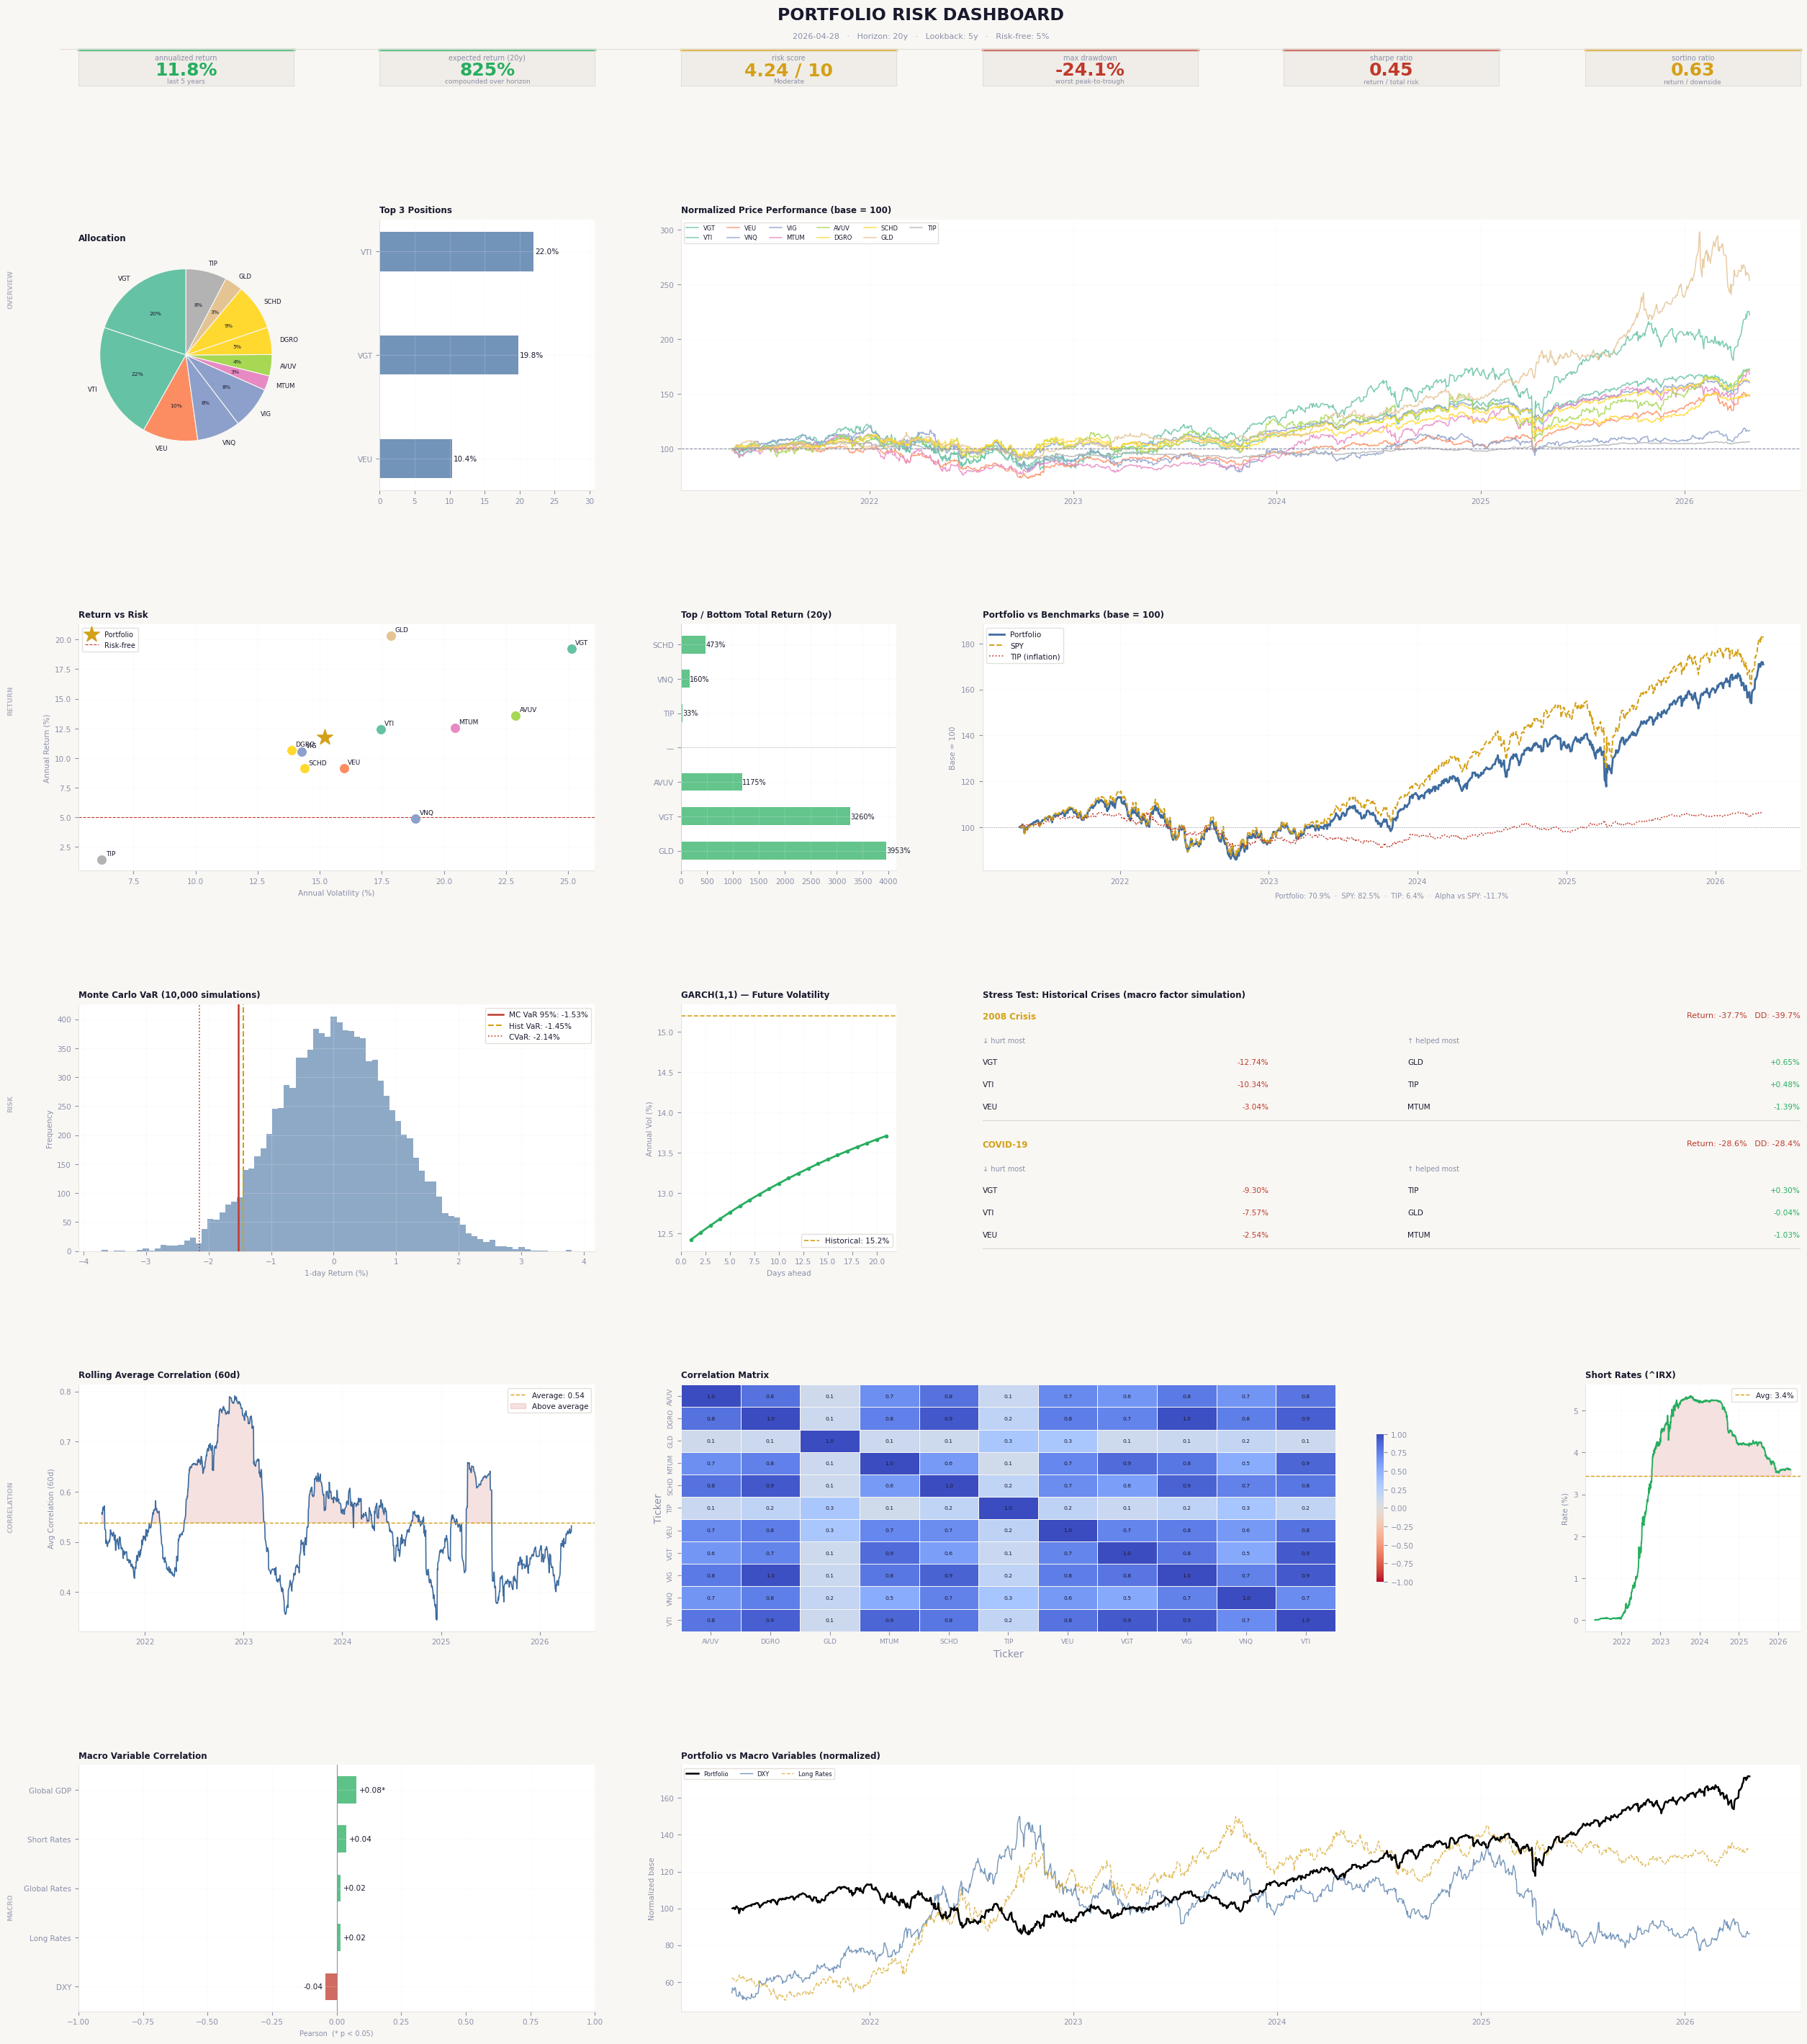


📁 Dashboard saved as: portfolio_risk_dashboard.png


{'metrics': {'returns': Ticker          AVUV      DGRO       GLD      MTUM      SCHD       TIP  \
  Date                                                                     
  2021-04-30 -0.016110 -0.004984 -0.003369 -0.007950 -0.005073 -0.000630   
  2021-05-03  0.021245  0.007213  0.012978 -0.006852  0.010198  0.002491   
  2021-05-04  0.000795  0.001193 -0.007330 -0.019529  0.006110  0.002287   
  2021-05-05  0.009665  0.001589  0.004142 -0.005426  0.004885  0.004485   
  2021-05-06  0.005638  0.009324  0.016680  0.001559  0.012611 -0.001175   
  ...              ...       ...       ...       ...       ...       ...   
  2026-04-22  0.003311  0.002199  0.013246  0.016201  0.000968  0.001528   
  2026-04-23  0.006093  0.003154 -0.009695 -0.000399  0.013222  0.001616   
  2026-04-24  0.000589 -0.005058  0.005127  0.018196 -0.007002  0.002062   
  2026-04-27  0.005464 -0.002611 -0.007755 -0.000534 -0.002244 -0.000268   
  2026-04-28 -0.002343 -0.000207 -0.018458 -0.016776  0.004337 -0.

In [4]:
my_portfolio = [
        {"ticker": "VGT",  "allocation": 0.1985},
        {"ticker": "VTI",  "allocation": 0.2200},
        {"ticker": "VEU",  "allocation": 0.1037},
        {"ticker": "VNQ",  "allocation": 0.0816},
        {"ticker": "VIG",  "allocation": 0.0799},
        {"ticker": "MTUM", "allocation": 0.0274},
        {"ticker": "AVUV", "allocation": 0.0401},
        {"ticker": "DGRO", "allocation": 0.0512},
        {"ticker": "SCHD", "allocation": 0.0871},
        {"ticker": "GLD",  "allocation": 0.0341},
        {"ticker": "TIP",  "allocation": 0.0767},
    ]

analyze_portfolio(my_portfolio, horizon_years=20)